# Statspeare

A Jupyter notebook exploration of Shakespeare's plays. Data manipulation for the Statspeare website that will display this data in an interactive format.

In [2]:
import warnings
import pandas as pd
import numpy as np
import sklearn as sk
import scipy as sp
import matplotlib.pyplot as plt
import time

In [3]:
data = pd.read_csv("shakespeare/Shakespeare_data.csv", engine='python')

warnings.filterwarnings('ignore')
data.head(10)

,Dataline,Play,PlayerLinenumber,ActSceneLine,Player,PlayerLine
0,1,Henry IV,NaN,NaN,NaN,ACT I
1,2,Henry IV,NaN,NaN,NaN,SCENE I. London. The palace.
2,3,Henry IV,NaN,NaN,NaN,"Enter KING HENRY, LORD JOHN OF LANCASTER, the ..."
3,4,Henry IV,1.0,1.1.1,KING HENRY IV,"So shaken as we are, so wan with care,"
4,5,Henry IV,1.0,1.1.2,KING HENRY IV,"Find we a time for frighted peace to pant,"
5,6,Henry IV,1.0,1.1.3,KING HENRY IV,And breathe short-winded accents of new broils
6,7,Henry IV,1.0,1.1.4,KING HENRY IV,To be commenced in strands afar remote.
7,8,Henry IV,1.0,1.1.5,KING HENRY IV,No more the thirsty entrance of this soil
8,9,Henry IV,1.0,1.1.6,KING HENRY IV,Shall daub her lips with her own children's bl...
9,10,Henry IV,1.0,1.1.7,KING HENRY IV,"Nor more shall trenching war channel her fields,"


## Data Exploration and Cleaning

In [5]:
data = data.dropna()
data = data.replace("Henry IV", "Henry IV Part 1")
data = data.replace("Alls well that ends well", "All's Well That Ends Well")
data = data.replace("Measure for measure", "Measure for Measure")
data = data.replace("Loves Labours Lost", "Love's Labour's Lost")
data = data.replace("As you like it", "As You Like It")
data = data.replace("Much Ado about nothing", "Much Ado About Nothing")
data = data.replace("macbeth", "Macbeth")
data = data.replace("A Midsummer nights dream", "A Midsummer Night's Dream")
Plays = data['Play'].unique()
data.head()

,Dataline,Play,PlayerLinenumber,ActSceneLine,Player,PlayerLine
3,4,Henry IV Part 1,1.0,1.1.1,KING HENRY IV,"So shaken as we are, so wan with care,"
4,5,Henry IV Part 1,1.0,1.1.2,KING HENRY IV,"Find we a time for frighted peace to pant,"
5,6,Henry IV Part 1,1.0,1.1.3,KING HENRY IV,And breathe short-winded accents of new broils
6,7,Henry IV Part 1,1.0,1.1.4,KING HENRY IV,To be commenced in strands afar remote.
7,8,Henry IV Part 1,1.0,1.1.5,KING HENRY IV,No more the thirsty entrance of this soil


In [7]:
line_counts = data['Play'].value_counts()
print(line_counts.index)

Index(['Hamlet', 'Coriolanus', 'Cymbeline', 'Richard III',
       'Antony and Cleopatra', 'Othello', 'King Lear', 'Troilus and Cressida',
       'A Winters Tale', 'Henry VIII', 'Henry V', 'Henry VI Part 2',
       'Romeo and Juliet', 'Henry IV Part 1', 'Henry VI Part 3',
       'All's Well That Ends Well', 'Love's Labour's Lost',
       'Measure for Measure', 'Richard II', 'Henry VI Part 1',
       'As You Like It', 'Merchant of Venice', 'King John',
       'Taming of the Shrew', 'Merry Wives of Windsor', 'Julius Caesar',
       'Much Ado About Nothing', 'Titus Andronicus', 'Timon of Athens',
       'Twelfth Night', 'Pericles', 'Macbeth', 'The Tempest',
       'Two Gentlemen of Verona', 'A Midsummer Night's Dream',
       'A Comedy of Errors'],
      dtype='object')


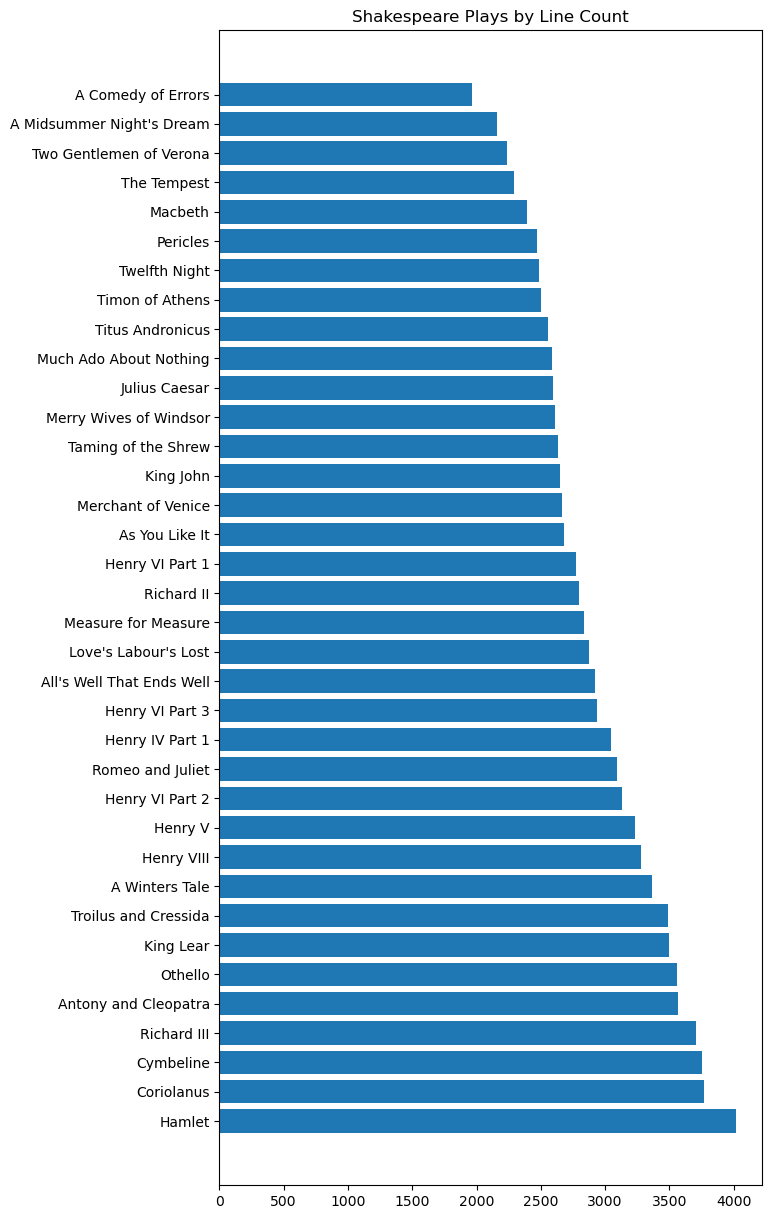

In [8]:
plt.figure(figsize=(7,15))
plt.barh(line_counts.index, line_counts.tolist())
plt.title("Shakespeare Plays by Line Count")
plt.show()


In [9]:
play_dfs = []
for play in line_counts.index.tolist():
    single_play = data.loc[data['Play'] == play]
    character_lines = single_play['Player'].value_counts()
    cl = character_lines.to_frame()
    cl.rename(columns={'Player':'Lines'}, inplace=True)
    cl.reset_index(level=0, inplace=True)
    cl.rename(columns={'index':'Characters'}, inplace=True)
    play_dfs.append(cl)
    

play_dfs[0]

,Characters,Lines
0,HAMLET,1503
1,KING CLAUDIUS,546
2,LORD POLONIUS,355
3,HORATIO,289
4,LAERTES,207
5,OPHELIA,173
6,QUEEN GERTRUDE,157
7,Ghost,95
8,First Clown,94
9,ROSENCRANTZ,93


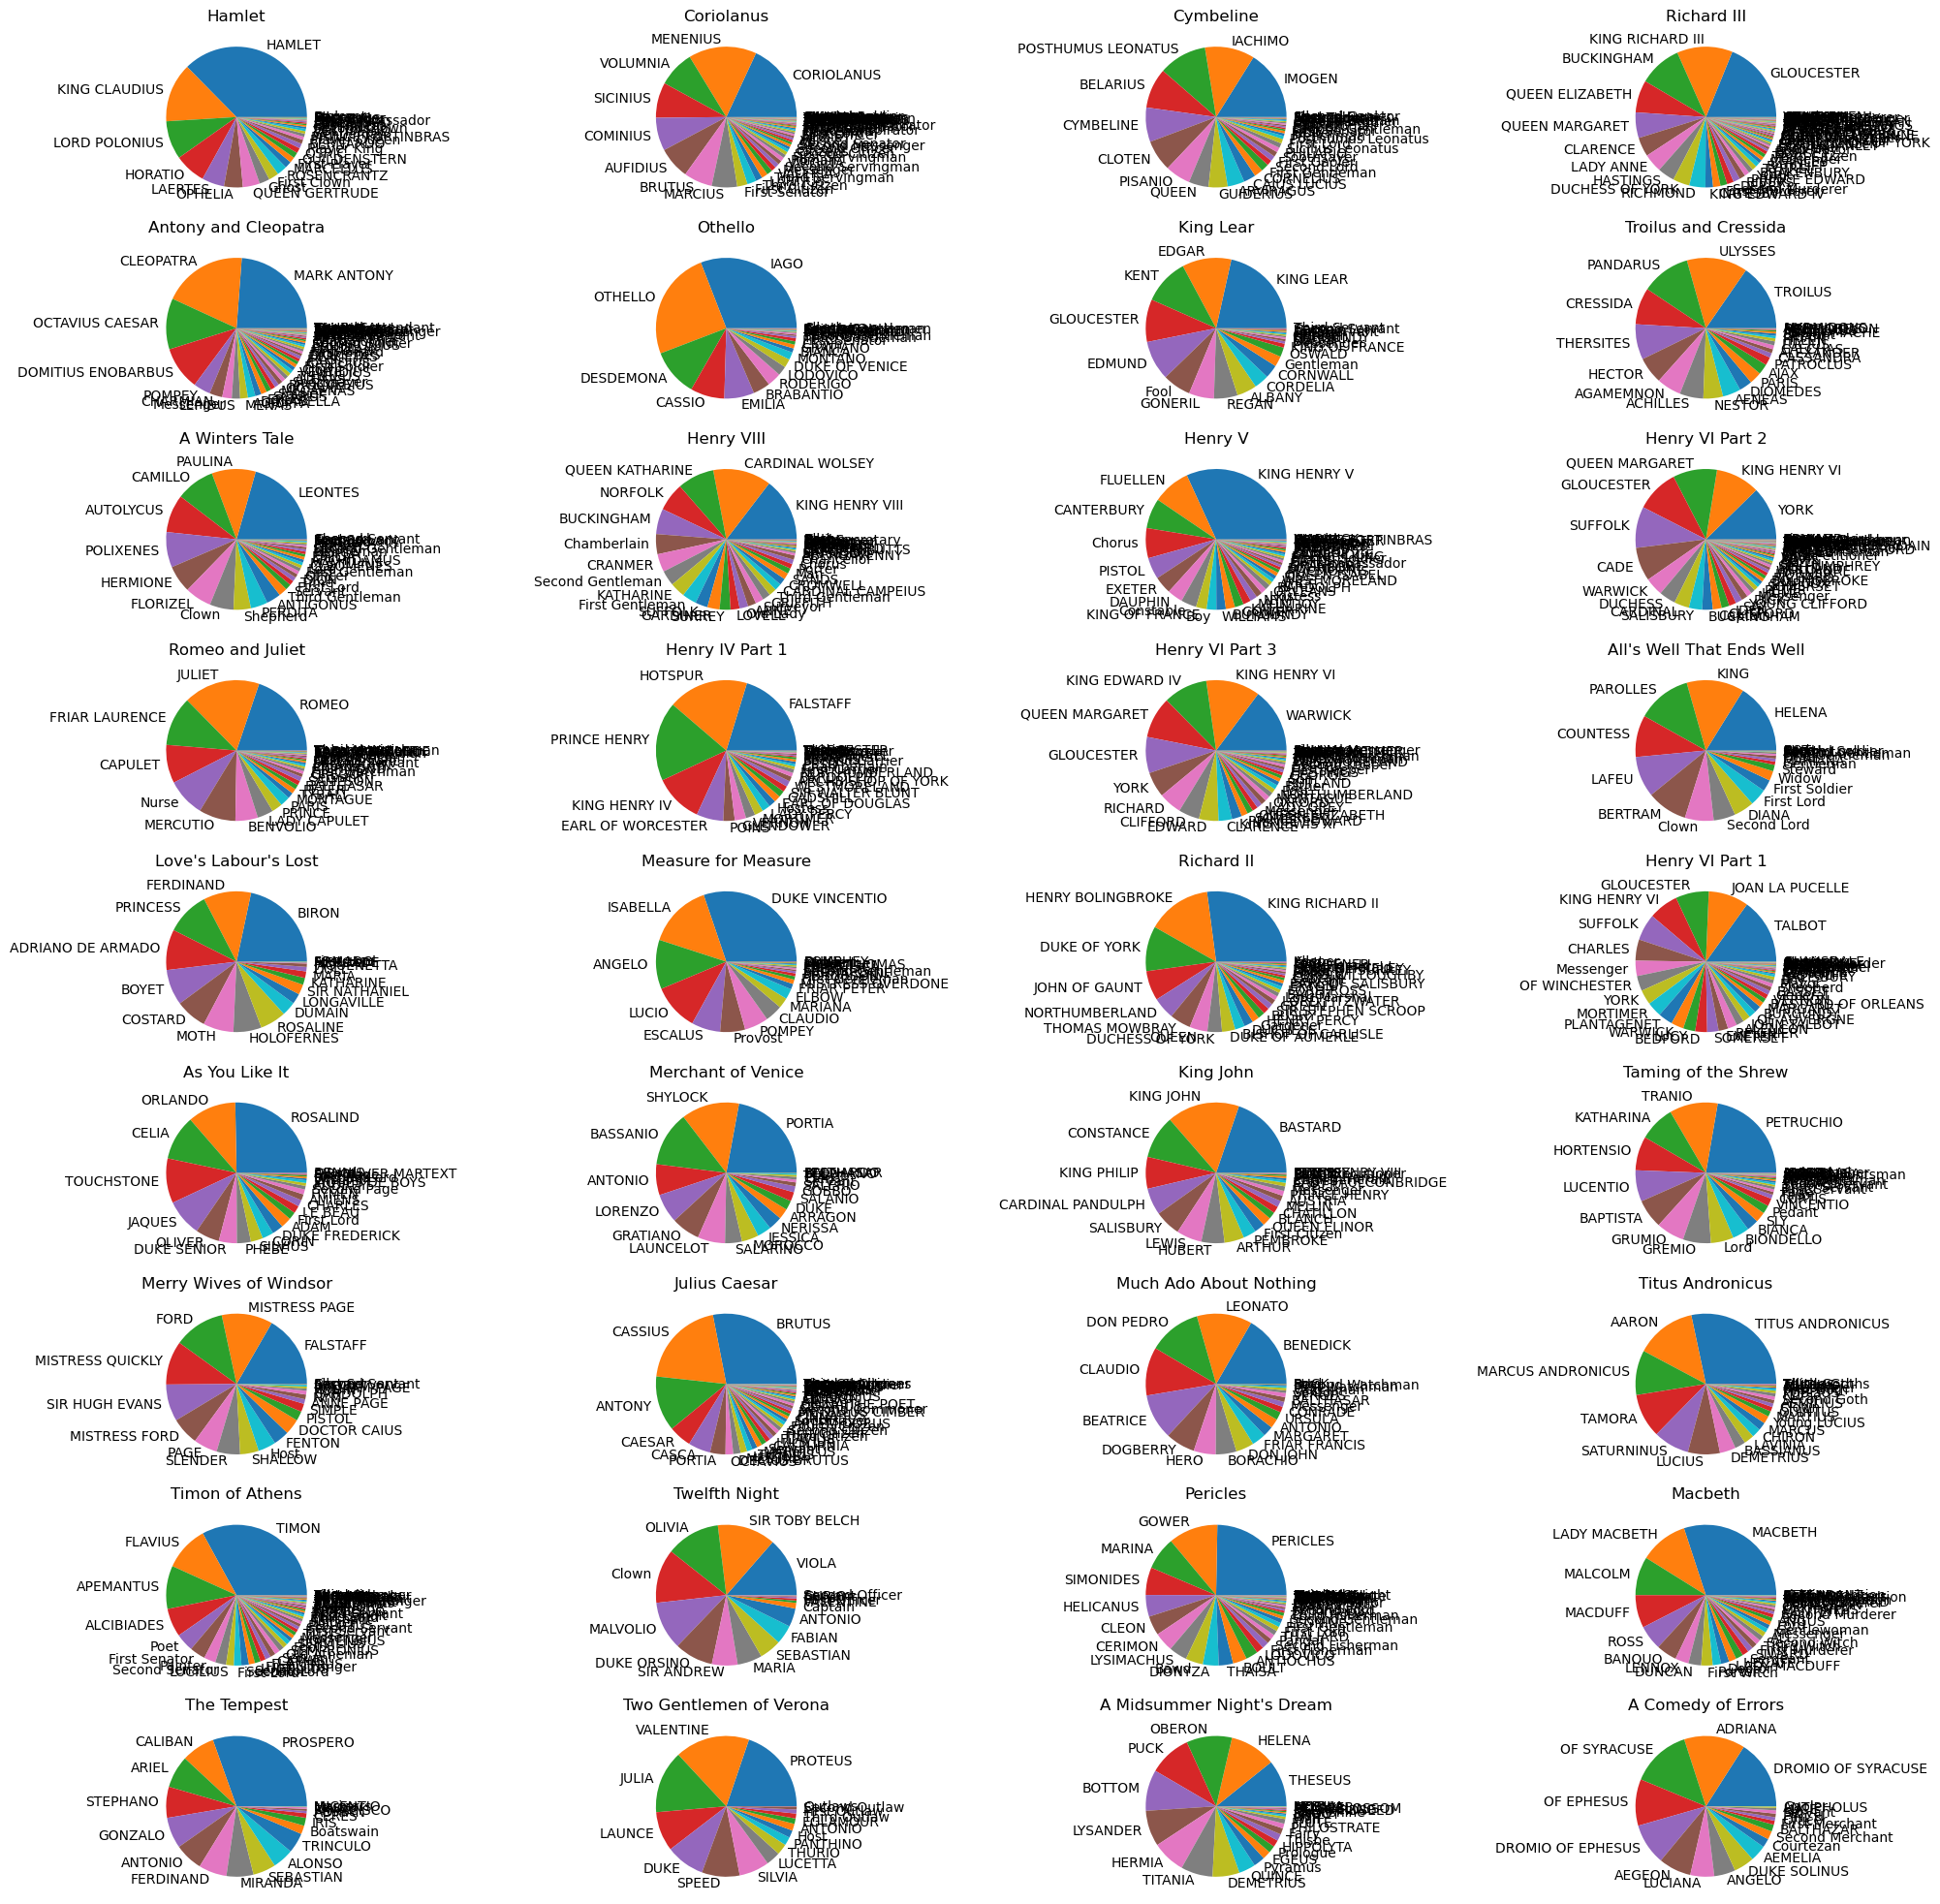

In [10]:
plt.subplots(9, 4, figsize=(25, 25))
i = 1
for play in play_dfs:
    plt.subplot(9, 4, i)
    plt.pie(play['Lines'], labels=play['Characters'])
    plt.title(line_counts.index.tolist()[i - 1])
    i += 1

In [12]:
play_names = line_counts.index.tolist()
for i in range(len(play_dfs)):
    play = play_dfs[i]
    play_name = play_names[i]
    play.to_csv("play_csvs/" + play_name + ".csv")
